# TI-501: Jaguar Analysis — IP-Level KPIs by Score Category

## Overview

**Ticket:** [TI-452](https://mntn.atlassian.net/browse/TI-452)

**Objective:** Compare IP-level KPIs between organic and Jaguar-added IPs, broken down by household score category.

**Approach:**
1. Extract IP-level KPIs from coredw including `household_score` from `cost_impression_log`
2. Join to `ip_vertical_associations` to get `is_model_added` flag
3. Categorize scores and aggregate KPIs by 8 groups: 4 score categories × 2 is_model_added values

## Key Optimization
Instead of joining to the 242B row `prospecting_intent` table, we use the `household_score` column already present in `cost_impression_log`. This is the **actual score used for bidding** at impression time.

## Data Sources

| Source | Tables | Purpose |
|--------|--------|----------|
| coredw (Greenplum) | `logdata.cost_impression_log`, `summarydata.ui_visits`, `summarydata.ui_conversions` | IP-level KPIs + household_score |
| GCS Parquet | `ip_vertical_associations` | is_model_added flag |

## Score Categories

| Score | Name | Meaning |
|-------|------|---------||
| 10000 | HI (High Intent) | Vertical + Keywords |
| 8000 | Peak Performance | Vertical only (no keywords) |
| 3333-6665 | MI (Mid Intent) | Bucket + Keywords |
| Other | Max Reach | Keywords only |

---
## 1. Setup & Imports

In [0]:
# =============================================================================
# IMPORTS
# =============================================================================

import json
from datetime import date, timedelta
from typing import Dict

from pyspark.sql import DataFrame, SparkSession
from pyspark.sql.functions import (
    col,
    count,
    countDistinct,
    sum as spark_sum,
    when,
    round as spark_round,
)
from pyspark.sql.types import DecimalType, DoubleType

import google.auth.transport.requests as g_request
from google.auth import compute_engine
import requests

import pandas as pd

# Initialize Spark session
spark = SparkSession.builder.appName("jaguar_kpi_by_score").getOrCreate()

print("Setup complete.")

Setup complete.


---
## 2. Configuration Parameters

In [0]:
# =============================================================================
# ANALYSIS PARAMETERS
# =============================================================================

# Jaguar release date
RELEASE_DATE = date(2025, 11, 25)

# KPI date range: starts day AFTER release, ends on a full week boundary
# Must end at least 1 day before today
START_DATE = RELEASE_DATE + timedelta(days=1)
latest_possible_end = date.today() - timedelta(days=1)

# Calculate full weeks available
days_available = (latest_possible_end - START_DATE).days + 1
full_weeks = days_available // 7

if full_weeks < 1:
    raise ValueError(f"Not enough days for a full week. Days available: {days_available}")

period_days = full_weeks * 7
END_DATE = START_DATE + timedelta(days=period_days - 1)

# Snapshot date for IP list - use END_DATE to capture all Jaguar-added IPs
SNAPSHOT_DATE = END_DATE

# Date strings for SQL
START_DATE_STR = START_DATE.strftime("%Y-%m-%d")
END_DATE_STR = END_DATE.strftime("%Y-%m-%d")
SNAPSHOT_DATE_STR = SNAPSHOT_DATE.strftime("%Y-%m-%d")

# Vertical filter
VERTICAL_IDS = [113002]

# =============================================================================
# DERIVED PATHS
# =============================================================================

# Use snapshot date (end of KPI period) for ip_vertical_associations
IP_VERT_PATH = f"gs://mntn-data-archive-prod/vertical_categorizations/ip_vertical_associations/dt={SNAPSHOT_DATE_STR}/"

print(f"Release Date:     {RELEASE_DATE}")
print(f"KPI Start Date:   {START_DATE} (day after release)")
print(f"KPI End Date:     {END_DATE}")
print(f"Snapshot Date:    {SNAPSHOT_DATE} (IP list as of this date)")
print(f"Full Weeks:       {full_weeks}")
print(f"KPI Period:       {period_days} days")
print(f"Vertical IDs:     {VERTICAL_IDS}")
print(f"IP Vert Path:     {IP_VERT_PATH}")

Release Date:     2025-11-25
KPI Start Date:   2025-11-26 (day after release)
KPI End Date:     2026-01-20
Snapshot Date:    2026-01-20 (IP list as of this date)
Full Weeks:       8
KPI Period:       56 days
Vertical IDs:     [113002]
IP Vert Path:     gs://mntn-data-archive-prod/vertical_categorizations/ip_vertical_associations/dt=2026-01-20/


---
## 3. Helper Functions

In [0]:
def token_for_url(url: str) -> str:
    """
    Get GCP identity token for the specified URL.
    Used for Vault authentication via workload identity.
    """
    request = g_request.Request()
    credentials = compute_engine.IDTokenCredentials(
        request=request,
        target_audience=url,
        use_metadata_identity_endpoint=True,
    )
    credentials.refresh(request)
    return credentials.token


def get_secret(secret_name: str) -> Dict:
    """
    Retrieve secret from Vault using GCP workload identity authentication.
    """
    vault_address = "https://vault.prod.in.mountain.com"
    role = "gcp-workloads"
    path = "shared/global/ti"

    jwt = token_for_url(f"{vault_address}/vault/gcp-workloads")

    auth_resp = requests.post(
        f"{vault_address}/v1/auth/gcp/login",
        headers={"Content-Type": "application/json"},
        data=json.dumps({"role": role, "jwt": jwt}),
    )
    auth_resp.raise_for_status()
    vault_token = auth_resp.json()["auth"]["client_token"]

    secret_resp = requests.get(
        f"{vault_address}/v1/secret/data/{path}/{secret_name}",
        headers={"X-Vault-Token": vault_token},
    )
    secret_resp.raise_for_status()

    return secret_resp.json().get("data", {}).get("data")


def load_postgres_query(query: str, session: SparkSession) -> DataFrame:
    """
    Execute a query against coredw (Greenplum) and return results as Spark DataFrame.
    """
    secrets = get_secret("coredw")

    return (
        session.read
        .format("jdbc")
        .option("url", f"jdbc:postgresql://{secrets['hostname']}:{secrets['port']}/{secrets['database']}")
        .option("dbtable", query)
        .option("user", secrets["username"])
        .option("password", secrets["password"])
        .option("driver", "org.postgresql.Driver")
        .load()
    )


print("Helper functions loaded.")

Helper functions loaded.


---
## 4. Build coredw Query

Extract IP-level KPIs from Greenplum **including household_score** from `cost_impression_log`.

Key optimization: Instead of joining to the 242B row prospecting_intent table, we use the `household_score` column that's already in `cost_impression_log`. This is the actual score used for bidding at impression time.

In [0]:
# Build vertical filter clause
if VERTICAL_IDS:
    vertical_filter = f"and av.vertical_id in ({','.join(map(str, VERTICAL_IDS))})"
else:
    vertical_filter = "-- all verticals (no filter)"

# =============================================================================
# IP-LEVEL KPI QUERY WITH SCORE CATEGORIES
# Uses household_score from cost_impression_log directly
# =============================================================================

COREDW_QUERY = f"""
(
    /* ------------------------------------------------------------------------
       Step 1: Get advertisers in target vertical(s)
       ------------------------------------------------------------------------ */
    with advertisers as (
        select distinct
            av.advertiser_id
          , av.vertical_id
          , av.vertical_name
        from fpa.advertiser_verticals av
        where 1 = 1
            and av.type = 1
            {vertical_filter}
    )
    
    /* ------------------------------------------------------------------------
       Step 2: Get Funnel 1 campaign groups
       ------------------------------------------------------------------------ */
    , campaign_groups as (
        select distinct
            a.advertiser_id
          , a.vertical_id
          , a.vertical_name
          , cgr.campaign_group_id
        from advertisers a
        inner join campaign_groups_raw cgr
            on cgr.advertiser_id = a.advertiser_id
        where 1 = 1
            and cgr.objective_id = 1
    )
    
    /* ------------------------------------------------------------------------
       Step 3: Map to individual campaigns
       ------------------------------------------------------------------------ */
    , campaigns as (
        select distinct
            cg.advertiser_id
          , cg.vertical_id
          , cg.vertical_name
          , cg.campaign_group_id
          , c.campaign_id
        from campaign_groups cg
        inner join public.campaigns c
            on c.campaign_group_id = cg.campaign_group_id
        where 1 = 1
            and (c.deleted is null or c.deleted = false)
    )
    
    /* ------------------------------------------------------------------------
       Step 4: Aggregate impressions, spend, and score by IP
       Categorize household_score into score buckets
       Uses MODE (most common score) for each IP
       ------------------------------------------------------------------------ */
    , impressions as (
        select
            cil.ip
          , count(*) as impressions
          , sum(
                coalesce(cil.media_spend, 0) 
              + coalesce(cil.data_spend, 0) 
              + coalesce(cil.platform_spend, 0)
            ) as spend
          , case 
                when mode() within group (order by cil.household_score) = 10000 then 'HI'
                when mode() within group (order by cil.household_score) = 8000 then 'Peak Performance'
                when mode() within group (order by cil.household_score) between 3333 and 6665 then 'MI'
                else 'Max Reach'
            end as score_category
        from logdata.cost_impression_log cil
        inner join campaigns c
            on c.campaign_id = cil.campaign_id
        where 1 = 1
            and cil.time >= '{START_DATE_STR}'::date
            and cil.time < '{END_DATE_STR}'::date + interval '1 day'
            and cil.ip is not null
        group by cil.ip
    )
    
    /* ------------------------------------------------------------------------
       Step 5: Aggregate verified visits by IP
       ------------------------------------------------------------------------ */
    , visits as (
        select
            host(uv.ip) as ip
          , count(*) as verified_visits
        from summarydata.ui_visits uv
        inner join campaigns c
            on c.campaign_id = uv.campaign_id
        where 1 = 1
            and uv.impression_time >= '{START_DATE_STR}'::date
            and uv.impression_time < '{END_DATE_STR}'::date + interval '1 day'
            and uv.ip is not null
        group by host(uv.ip)
    )
    
    /* ------------------------------------------------------------------------
       Step 6: Aggregate conversions and order value by IP
       ------------------------------------------------------------------------ */
    , conversions as (
        select
            uc.ip
          , count(*) as conversions
          , sum(coalesce(uc.order_amt, 0)) as order_value
        from summarydata.ui_conversions uc
        inner join campaigns c
            on c.campaign_id = uc.campaign_id
        where 1 = 1
            and uc.impression_time >= '{START_DATE_STR}'::date
            and uc.impression_time < '{END_DATE_STR}'::date + interval '1 day'
            and uc.ip is not null
        group by uc.ip
    )
    
    /* ------------------------------------------------------------------------
       Step 7: Combine into final IP-level output with score category
       ------------------------------------------------------------------------ */
    select
        i.ip
      , i.score_category
      , i.impressions
      , i.spend
      , coalesce(v.verified_visits, 0) as verified_visits
      , coalesce(c.conversions, 0) as conversions
      , coalesce(c.order_value, 0) as order_value
    from impressions i
    left join visits v
        on v.ip = i.ip
    left join conversions c
        on c.ip = i.ip
    where 1 = 1
        and i.impressions > 0
) as ip_kpis
"""

print("Query built successfully.")
print(f"\nVertical filter: {vertical_filter}")
print(f"Date range: {START_DATE_STR} to {END_DATE_STR}")

Query built successfully.

Vertical filter: and av.vertical_id in (113002)
Date range: 2025-11-26 to 2026-01-20


---
## 5. Load IP KPIs from coredw

In [0]:
# Load IP-level KPIs from coredw
ip_kpis_df = load_postgres_query(COREDW_QUERY, spark)

# Cache for reuse
ip_kpis_df.cache()

ip_count = ip_kpis_df.count()
print(f"Loaded {ip_count:,} IPs from coredw")
print("\nSchema:")
ip_kpis_df.printSchema()

Loaded 14,908,114 IPs from coredw

Schema:
root
 |-- ip: string (nullable = true)
 |-- score_category: string (nullable = true)
 |-- impressions: long (nullable = true)
 |-- spend: decimal(38,18) (nullable = true)
 |-- verified_visits: long (nullable = true)
 |-- conversions: long (nullable = true)
 |-- order_value: decimal(38,18) (nullable = true)



In [0]:
# Validation: Check aggregate totals
print("Aggregate Validation (coredw):")
print("=" * 60)

validation = ip_kpis_df.selectExpr(
    "count(*) as total_ips",
    "sum(impressions) as total_impressions",
    "sum(spend) as total_spend",
    "sum(verified_visits) as total_vv",
    "sum(conversions) as total_conversions",
    "sum(order_value) as total_order_value"
).collect()[0]

print(f"Total IPs:          {validation['total_ips']:,}")
print(f"Total Impressions:  {validation['total_impressions']:,}")
print(f"Total Spend:        ${float(validation['total_spend']):,.2f}")
print(f"Total VV:           {validation['total_vv']:,}")
print(f"Total Conversions:  {validation['total_conversions']:,}")
print(f"Total Order Value:  ${float(validation['total_order_value']):,.2f}")

Aggregate Validation (coredw):
Total IPs:          14,908,114
Total Impressions:  167,183,314
Total Spend:        $2,261,490.02
Total VV:           878,121
Total Conversions:  14,562
Total Order Value:  $1,178,384.33


In [0]:
# Validation: Score category distribution
print("\nScore Category Distribution:")
print("=" * 50)

(
    ip_kpis_df
    .groupBy("score_category")
    .agg(
        count("*").alias("ip_count"),
        spark_sum("impressions").alias("impressions")
    )
    .orderBy("score_category")
    .show()
)


Score Category Distribution:
+----------------+--------+-----------+
|  score_category|ip_count|impressions|
+----------------+--------+-----------+
|              HI| 1803946|   15051090|
|              MI|  564393|    1162710|
|       Max Reach|11066961|  146036121|
|Peak Performance| 1472814|    4933393|
+----------------+--------+-----------+



---
## 6. Load IP Vertical Associations

In [0]:
# Load IP vertical associations
ip_vert_raw_df = spark.read.parquet(IP_VERT_PATH)

# Filter to target vertical(s)
if VERTICAL_IDS:
    ip_vert_df = ip_vert_raw_df.filter(
        col("data_source_category_id").isin([float(v) for v in VERTICAL_IDS])
    )
else:
    ip_vert_df = ip_vert_raw_df

# Get distinct IP + is_model_added
ip_vert_filtered_df = (
    ip_vert_df
    .select("ip", "is_model_added")
    .distinct()
    .cache()
)

print(f"Loaded {ip_vert_filtered_df.count():,} IP-vertical associations")

Loaded 23,780,176 IP-vertical associations


In [0]:
# Validation: IP distribution by is_model_added
print("IP Distribution by is_model_added:")
print("=" * 50)

(
    ip_vert_filtered_df
    .groupBy("is_model_added")
    .agg(count("*").alias("unique_ips"))
    .orderBy("is_model_added")
    .show()
)

IP Distribution by is_model_added:
+--------------+----------+
|is_model_added|unique_ips|
+--------------+----------+
|         false|  23374110|
|          true|    406066|
+--------------+----------+



In [0]:
# =============================================================================
# MODEL SCORE vs IVR CORRELATION ANALYSIS
# =============================================================================

from pyspark.sql.functions import floor, lit, concat

# Step 1: Load ip_vertical_associations WITH model_score
ip_vert_with_score_df = (
    ip_vert_raw_df
    .filter(col("data_source_category_id").isin([float(v) for v in VERTICAL_IDS]))
    .select("ip", "is_model_added", "model_score")
    .distinct()
)

# Step 2: Join to IP KPIs
score_analysis_df = (
    ip_kpis_df
    .join(ip_vert_with_score_df, on="ip", how="inner")
)

# Step 3: Bucket model_score into deciles (0.0-0.1, 0.1-0.2, etc.)
# Handle nulls and edge case where score = 1.0
score_analysis_df = score_analysis_df.withColumn(
    "score_bucket",
    when(col("model_score").isNull(), "NULL")
    .when(col("model_score") >= 1.0, "0.9-1.0")  # Include 1.0 in top bucket
    .otherwise(
        concat(
            (floor(col("model_score") * 10) / 10).cast("string"),
            lit("-"),
            ((floor(col("model_score") * 10) + 1) / 10).cast("string")
        )
    )
)

# Step 4: Aggregate by bucket + is_model_added
score_ivr_agg = (
    score_analysis_df
    .groupBy("score_bucket", "is_model_added")
    .agg(
        countDistinct("ip").alias("unique_ips"),
        spark_sum("impressions").alias("impressions"),
        spark_sum("verified_visits").alias("verified_visits")
    )
    .withColumn("ivr", col("verified_visits") / col("impressions"))
    .orderBy("score_bucket", "is_model_added")
)

# Convert to pandas for plotting
score_ivr_pd = score_ivr_agg.toPandas()
display(score_ivr_pd)

score_bucket,is_model_added,unique_ips,impressions,verified_visits,ivr
0.3-0.4,true,95878,2416832,2656,0.0010989592987845245
0.4-0.5,true,49142,1453827,2067,0.001421764762932591
0.5-0.6,true,11606,367136,694,0.001890307678898283
0.6-0.7,true,2816,76600,207,0.002702349869451697
0.7-0.8,true,555,14287,58,0.004059634632883041
0.8-0.9,true,29,702,2,0.002849002849002849
NULL,false,4942268,83319319,843754,0.010126751035975223


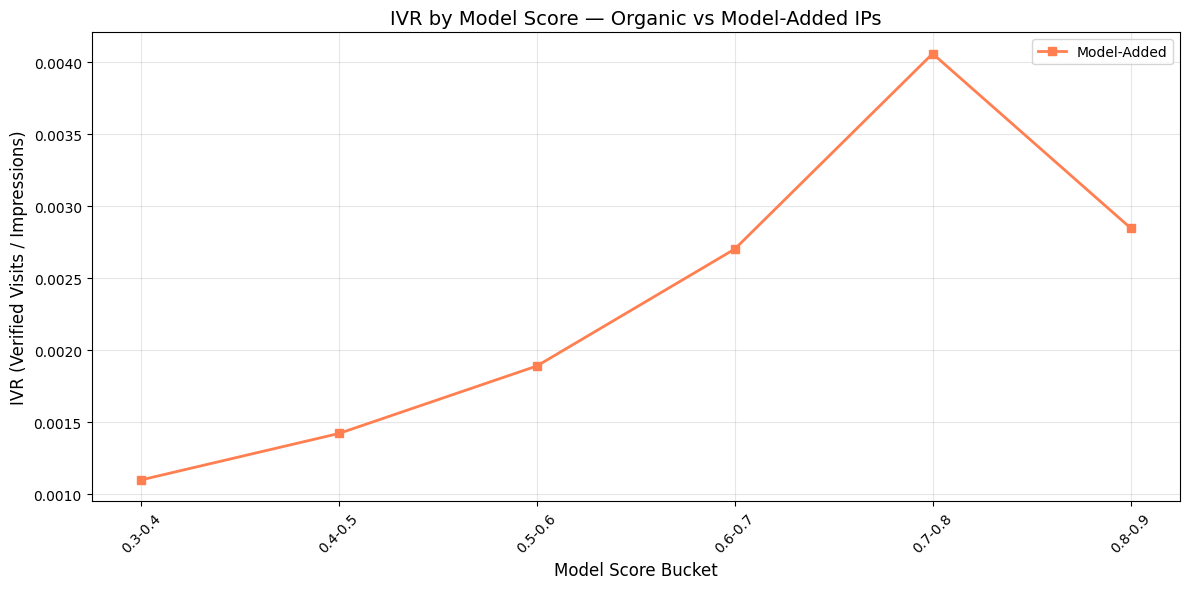

In [0]:
# =============================================================================
# PLOT: MODEL SCORE vs IVR BY IS_MODEL_ADDED
# =============================================================================

import matplotlib.pyplot as plt

# Filter out NULL bucket for cleaner viz
plot_df = score_ivr_pd[score_ivr_pd["score_bucket"] != "NULL"].copy()

# Pivot for easier plotting
organic = plot_df[plot_df["is_model_added"] == False].sort_values("score_bucket")
model_added = plot_df[plot_df["is_model_added"] == True].sort_values("score_bucket")

fig, ax = plt.subplots(figsize=(12, 6))

x_labels = sorted(plot_df["score_bucket"].unique())

if not organic.empty:
    organic_ivr = organic.set_index("score_bucket").reindex(x_labels)["ivr"]
    ax.plot(x_labels, organic_ivr.values, marker="o", linewidth=2, label="Organic", color="steelblue")

if not model_added.empty:
    model_ivr = model_added.set_index("score_bucket").reindex(x_labels)["ivr"]
    ax.plot(x_labels, model_ivr.values, marker="s", linewidth=2, label="Model-Added", color="coral")

ax.set_xlabel("Model Score Bucket", fontsize=12)
ax.set_ylabel("IVR (Verified Visits / Impressions)", fontsize=12)
ax.set_title("IVR by Model Score — Organic vs Model-Added IPs", fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [0]:
# =============================================================================
# MODEL SCORE vs IVR CORRELATION ANALYSIS
# =============================================================================

from pyspark.sql.functions import rand

# Step 1: Load ip_vertical_associations WITH model_score
ip_vert_with_score_df = (
    ip_vert_raw_df
    .filter(col("data_source_category_id").isin([float(v) for v in VERTICAL_IDS]))
    .select("ip", "is_model_added", "model_score")
    .distinct()
)

# Step 2: Join to IP KPIs and calculate IVR
score_analysis_df = (
    ip_kpis_df
    .join(ip_vert_with_score_df, on="ip", how="inner")
    .withColumn("ivr", col("verified_visits") / col("impressions"))
    .filter(col("model_score").isNotNull())
    .filter(col("ivr").isNotNull())
)

# Step 3: Convert to pandas (sample if too large)
row_count = score_analysis_df.count()
print(f"Total rows with model_score: {row_count:,}")

if row_count > 100000:
    sample_frac = 100000 / row_count
    print(f"Sampling {sample_frac:.2%} for visualization")
    plot_df = score_analysis_df.sample(fraction=sample_frac, seed=42).toPandas()
else:
    plot_df = score_analysis_df.toPandas()

print(f"Rows for plotting: {len(plot_df):,}")

Total rows with model_score: 160,026
Sampling 62.49% for visualization


/databricks/spark/python/pyspark/sql/pandas/utils.py:149: UserWarning: The conversion of DecimalType columns is inefficient and may take a long time. Column names: [spend, order_value] If those columns are not necessary, you may consider dropping them or converting to primitive types before the conversion.
  warnings.warn(


Rows for plotting: 100,135


Spearman Correlations (model_score vs IVR):
  Organic:     insufficient data
  Model-Added: r = 0.0519, p = 1.05e-60


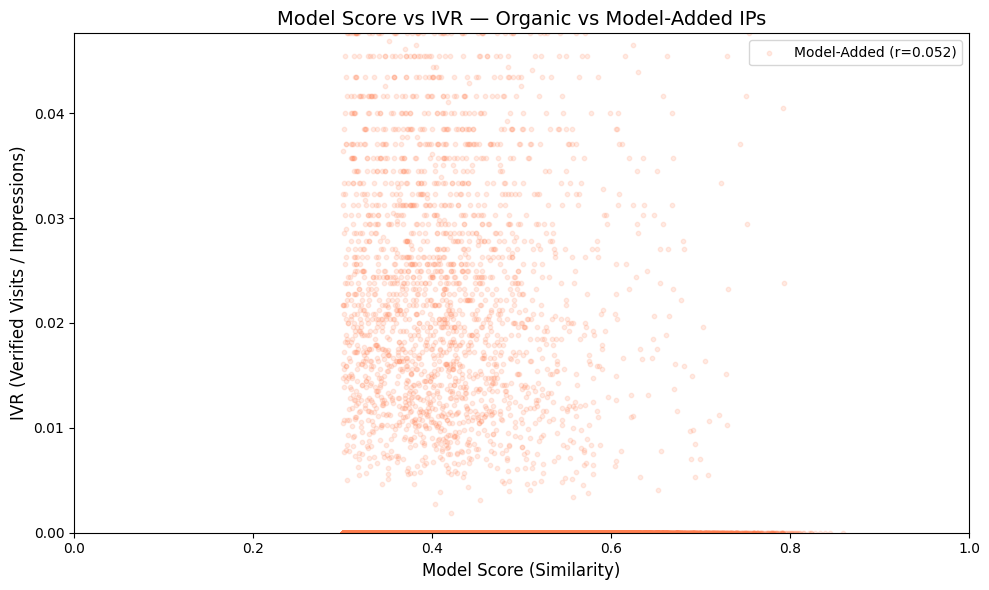

In [0]:
# =============================================================================
# SCATTER PLOT + CORRELATION COEFFICIENTS
# =============================================================================

import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Split by is_model_added
organic = plot_df[plot_df["is_model_added"] == False]
model_added = plot_df[plot_df["is_model_added"] == True]

# Calculate Spearman correlations
corr_organic, p_organic = spearmanr(organic["model_score"], organic["ivr"]) if len(organic) > 2 else (None, None)
corr_model, p_model = spearmanr(model_added["model_score"], model_added["ivr"]) if len(model_added) > 2 else (None, None)

print("Spearman Correlations (model_score vs IVR):")
print(f"  Organic:     r = {corr_organic:.4f}, p = {p_organic:.2e}" if corr_organic else "  Organic:     insufficient data")
print(f"  Model-Added: r = {corr_model:.4f}, p = {p_model:.2e}" if corr_model else "  Model-Added: insufficient data")

# Scatter plot
fig, ax = plt.subplots(figsize=(10, 6))

if not organic.empty:
    ax.scatter(organic["model_score"], organic["ivr"], alpha=0.15, s=10, 
               label=f"Organic (r={corr_organic:.3f})" if corr_organic else "Organic", color="steelblue")

if not model_added.empty:
    ax.scatter(model_added["model_score"], model_added["ivr"], alpha=0.15, s=10,
               label=f"Model-Added (r={corr_model:.3f})" if corr_model else "Model-Added", color="coral")

ax.set_xlabel("Model Score (Similarity)", fontsize=12)
ax.set_ylabel("IVR (Verified Visits / Impressions)", fontsize=12)
ax.set_title("Model Score vs IVR — Organic vs Model-Added IPs", fontsize=14)
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, plot_df["ivr"].quantile(0.99))  # Trim outliers for readability
plt.tight_layout()
plt.show()

---
## 7. Join IP KPIs to Vertical Classification

In [0]:
# Join IP KPIs + is_model_added
joined_df = ip_kpis_df.join(
    ip_vert_filtered_df,
    on="ip",
    how="inner"
).cache()

print(f"IPs after joining to vertical associations: {joined_df.count():,}")

IPs after joining to vertical associations: 5,102,294


In [0]:
# Validation: Check join results by group
print("\nJoin Validation - IP counts by group:")
print("=" * 60)

(
    joined_df
    .groupBy("is_model_added", "score_category")
    .agg(countDistinct("ip").alias("unique_ips"))
    .orderBy("is_model_added", "score_category")
    .show(truncate=False)
)


Join Validation - IP counts by group:
+--------------+----------------+----------+
|is_model_added|score_category  |unique_ips|
+--------------+----------------+----------+
|false         |HI              |1034984   |
|false         |MI              |57581     |
|false         |Max Reach       |3344462   |
|false         |Peak Performance|505241    |
|true          |HI              |28405     |
|true          |MI              |335       |
|true          |Max Reach       |129443    |
|true          |Peak Performance|1843      |
+--------------+----------------+----------+



---
## 8. Aggregate KPIs by Group

Calculate KPIs for each of the 8 groups (4 score categories × 2 is_model_added values).

| KPI | Formula | Interpretation |
|-----|---------|----------------|
| CPA | spend / conversions | Lower is better |
| CPV | spend / verified_visits | Lower is better |
| ROAS | order_value / spend | Higher is better |
| AOV | order_value / conversions | Higher is better |
| CVR | conversions / verified_visits | Higher is better |
| VVR | verified_visits / households | Higher is better |
| IVR | verified_visits / impressions | Higher is better |

In [0]:
# Aggregate volume metrics by is_model_added × score_category
kpi_agg_df = joined_df.groupBy("is_model_added", "score_category").agg(
    # Volume metrics
    countDistinct("ip").alias("households_reached"),
    spark_sum("impressions").alias("impressions"),
    spark_sum("spend").alias("spend"),
    spark_sum("verified_visits").alias("verified_visits"),
    spark_sum("conversions").alias("conversions"),
    spark_sum("order_value").alias("order_value")
)

# Add calculated efficiency KPIs
kpi_comparison_df = (
    kpi_agg_df
    .withColumn(
        "cpa", 
        when(col("conversions") > 0, col("spend") / col("conversions"))
    )
    .withColumn(
        "cpv",
        when(col("verified_visits") > 0, col("spend") / col("verified_visits"))
    )
    .withColumn(
        "roas",
        when(col("spend") > 0, col("order_value") / col("spend"))
    )
    .withColumn(
        "aov",
        when(col("conversions") > 0, col("order_value") / col("conversions"))
    )
    .withColumn(
        "cvr",
        when(col("verified_visits") > 0, col("conversions") / col("verified_visits"))
    )
    .withColumn(
        "vvr",
        when(col("households_reached") > 0, col("verified_visits") / col("households_reached"))
    )
    .withColumn(
        "ivr",
        when(col("impressions") > 0, col("verified_visits") / col("impressions"))
    )
    .orderBy("is_model_added", "score_category")
)

print("KPI aggregation complete.")

KPI aggregation complete.


---
## 9. Display Results

In [0]:
# Display raw results
print("=" * 80)
print("JAGUAR ANALYSIS: KPIs by Score Category")
print(f"Date Range: {START_DATE_STR} to {END_DATE_STR} | Vertical(s): {VERTICAL_IDS}")
print("=" * 80)

kpi_comparison_df.show(truncate=False)

JAGUAR ANALYSIS: KPIs by Score Category
Date Range: 2025-11-26 to 2026-01-20 | Vertical(s): [113002]
+--------------+----------------+------------------+-----------+-------------------------+---------------+-----------+-------------------------+-----------------------+---------------------+--------+---------------------+--------------------+--------------------+---------------------+
|is_model_added|score_category  |households_reached|impressions|spend                    |verified_visits|conversions|order_value              |cpa                    |cpv                  |roas    |aov                  |cvr                 |vvr                 |ivr                  |
+--------------+----------------+------------------+-----------+-------------------------+---------------+-----------+-------------------------+-----------------------+---------------------+--------+---------------------+--------------------+--------------------+---------------------+
|false         |HI              |1034984 

In [0]:
# Convert to pandas for better formatting
# Cast decimal columns to double first
kpi_clean_df = kpi_comparison_df
for field in kpi_clean_df.schema.fields:
    if isinstance(field.dataType, DecimalType):
        kpi_clean_df = kpi_clean_df.withColumn(
            field.name, 
            col(field.name).cast(DoubleType())
        )

kpi_results = kpi_clean_df.toPandas()

# Create readable group names
kpi_results["group"] = kpi_results.apply(
    lambda x: f"{'Model-Added' if x['is_model_added'] else 'Organic'} - {x['score_category']}",
    axis=1
)

# Reorder columns
display_cols = [
    "group", "households_reached", "impressions", "spend", 
    "verified_visits", "conversions", "order_value",
    "cpa", "cpv", "roas", "aov", "cvr", "vvr", "ivr"
]
kpi_display = kpi_results[display_cols].copy()

# Format numeric columns
kpi_display["spend"] = kpi_display["spend"].apply(lambda x: f"${x:,.2f}" if pd.notna(x) else "")
kpi_display["order_value"] = kpi_display["order_value"].apply(lambda x: f"${x:,.2f}" if pd.notna(x) else "")
kpi_display["cpa"] = kpi_display["cpa"].apply(lambda x: f"${x:,.2f}" if pd.notna(x) else "N/A")
kpi_display["cpv"] = kpi_display["cpv"].apply(lambda x: f"${x:,.2f}" if pd.notna(x) else "N/A")
kpi_display["roas"] = kpi_display["roas"].apply(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")
kpi_display["aov"] = kpi_display["aov"].apply(lambda x: f"${x:,.2f}" if pd.notna(x) else "N/A")
kpi_display["cvr"] = kpi_display["cvr"].apply(lambda x: f"{x*100:.2f}%" if pd.notna(x) else "N/A")
kpi_display["vvr"] = kpi_display["vvr"].apply(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")
kpi_display["ivr"] = kpi_display["ivr"].apply(lambda x: f"{x:.6f}" if pd.notna(x) else "N/A")

print("\n📊 FULL KPI COMPARISON BY GROUP")
print("=" * 80)
display(kpi_display)


📊 FULL KPI COMPARISON BY GROUP


group,households_reached,impressions,spend,verified_visits,conversions,order_value,cpa,cpv,roas,aov,cvr,vvr,ivr
Organic - HI,1034984,11152829,"$284,743.10",247477,4379,"$371,728.10",$65.02,$1.15,1.3055,$84.89,1.77%,0.2391,0.022190
Organic - MI,57581,141537,"$3,762.17",1243,16,"$1,095.20",$235.14,$3.03,0.2911,$68.45,1.29%,0.0216,0.008782
Organic - Max Reach,3344462,70439853,"$868,316.11",587337,9746,"$771,275.10",$89.09,$1.48,0.8882,$79.14,1.66%,0.1756,0.008338
Organic - Peak Performance,505241,1585100,"$39,244.67",7697,105,"$6,646.95",$373.76,$5.10,0.1694,$63.30,1.36%,0.0152,0.004856
Model-Added - HI,28405,426580,"$9,608.64",917,12,$917.39,$800.72,$10.48,0.0955,$76.45,1.31%,0.0323,0.002150
Model-Added - MI,335,935,$25.73,7,0,$0.00,N/A,$3.68,0.0000,N/A,0.00%,0.0209,0.007487
Model-Added - Max Reach,129443,3896280,"$47,636.09",4743,47,"$2,836.84","$1,013.53",$10.04,0.0596,$60.36,0.99%,0.0366,0.001217
Model-Added - Peak Performance,1843,5589,$141.65,17,0,$0.00,N/A,$8.33,0.0000,N/A,0.00%,0.0092,0.003042


In [0]:
# Create pivoted comparison: Organic vs Model-Added for each score category
print("\n📈 SIDE-BY-SIDE COMPARISON: Model-Added vs Organic")
print("=" * 80)

# Pivot for each KPI
kpi_results["model_type"] = kpi_results["is_model_added"].map({True: "Model-Added", False: "Organic"})

metrics = ["households_reached", "impressions", "spend", "verified_visits", 
           "conversions", "order_value", "cpa", "cpv", "roas", "aov", "cvr", "vvr", "ivr"]

for metric in metrics:
    pivot = kpi_results.pivot(
        index="score_category",
        columns="model_type",
        values=metric
    ).reindex(["HI", "Peak Performance", "MI", "Max Reach"])
    
    # Calculate % difference
    if "Organic" in pivot.columns and "Model-Added" in pivot.columns:
        pivot["Pct_Diff"] = (
            (pivot["Model-Added"] - pivot["Organic"]) 
            / pivot["Organic"].replace(0, float('nan')) 
            * 100
        ).round(2)
    
    # print(f"\n{metric.upper()}:")
    # display(pivot)


📈 SIDE-BY-SIDE COMPARISON: Model-Added vs Organic


---
## 10. Summary & Interpretation

In [0]:
# Calculate summary statistics for HI category (primary comparison)
print("=" * 80)
print("SUMMARY: HI (High Intent) Category Comparison")
print("=" * 80)

hi_organic = kpi_results[(kpi_results["score_category"] == "HI") & (kpi_results["is_model_added"] == False)]
hi_model = kpi_results[(kpi_results["score_category"] == "HI") & (kpi_results["is_model_added"] == True)]

if not hi_organic.empty and not hi_model.empty:
    print("\n                        Organic      Model-Added    Difference")
    print("-" * 70)
    
    for metric in ["households_reached", "impressions", "spend", "verified_visits", "conversions"]:
        org_val = hi_organic[metric].values[0]
        mod_val = hi_model[metric].values[0]
        pct_diff = ((mod_val - org_val) / org_val * 100) if org_val > 0 else 0
        print(f"{metric:20s}  {org_val:>12,.0f}  {mod_val:>12,.0f}  {pct_diff:>+10.1f}%")
    
    print("")
    for metric in ["cpa", "cpv", "roas", "aov", "cvr", "vvr", "ivr"]:
        org_val = hi_organic[metric].values[0]
        mod_val = hi_model[metric].values[0]
        if pd.notna(org_val) and pd.notna(mod_val) and org_val > 0:
            pct_diff = ((mod_val - org_val) / org_val * 100)
            print(f"{metric.upper():20s}  {org_val:>12,.4f}  {mod_val:>12,.4f}  {pct_diff:>+10.1f}%")
else:
    print("Insufficient data for HI category comparison.")

SUMMARY: HI (High Intent) Category Comparison

                        Organic      Model-Added    Difference
----------------------------------------------------------------------
households_reached       1,034,984        28,405       -97.3%
impressions             11,152,829       426,580       -96.2%
spend                      284,743         9,609       -96.6%
verified_visits            247,477           917       -99.6%
conversions                  4,379            12       -99.7%

CPA                        65.0247      800.7199     +1131.4%
CPV                         1.1506       10.4783      +810.7%
ROAS                        1.3055        0.0955       -92.7%
AOV                        84.8888       76.4492        -9.9%
CVR                         0.0177        0.0131       -26.0%
VVR                         0.2391        0.0323       -86.5%
IVR                         0.0222        0.0021       -90.3%


In [0]:
# Calculate summary statistics for Peak Performance category
print("=" * 80)
print("SUMMARY: Peak Performance Category Comparison")
print("=" * 80)
pp_organic = kpi_results[(kpi_results["score_category"] == "Peak Performance") & (kpi_results["is_model_added"] == False)]
pp_model = kpi_results[(kpi_results["score_category"] == "Peak Performance") & (kpi_results["is_model_added"] == True)]
if not pp_organic.empty and not pp_model.empty:
    print("\n                        Organic      Model-Added    Difference")
    print("-" * 70)
    for metric in ["households_reached", "impressions", "spend", "verified_visits", "conversions"]:
        org_val = pp_organic[metric].values[0]
        mod_val = pp_model[metric].values[0]
        pct_diff = ((mod_val - org_val) / org_val * 100) if org_val > 0 else 0
        print(f"{metric:20s}  {org_val:>12,.0f}  {mod_val:>12,.0f}  {pct_diff:>+10.1f}%")
    print("")
    for metric in ["cpa", "cpv", "roas", "aov", "cvr", "vvr", "ivr"]:
        org_val = pp_organic[metric].values[0]
        mod_val = pp_model[metric].values[0]
        if pd.notna(org_val) and pd.notna(mod_val) and org_val > 0:
            pct_diff = ((mod_val - org_val) / org_val * 100)
            print(f"{metric.upper():20s}  {org_val:>12,.4f}  {mod_val:>12,.4f}  {pct_diff:>+10.1f}%")
else:
    print("Insufficient data for Peak Performance category comparison.")

SUMMARY: Peak Performance Category Comparison

                        Organic      Model-Added    Difference
----------------------------------------------------------------------
households_reached         505,241         1,843       -99.6%
impressions              1,585,100         5,589       -99.6%
spend                       39,245           142       -99.6%
verified_visits              7,697            17       -99.8%
conversions                    105             0      -100.0%

CPV                         5.0987        8.3322       +63.4%
ROAS                        0.1694        0.0000      -100.0%
CVR                         0.0136        0.0000      -100.0%
VVR                         0.0152        0.0092       -39.5%
IVR                         0.0049        0.0030       -37.4%


In [0]:
# Calculate summary statistics for MI category
print("=" * 80)
print("SUMMARY: MI (Mid Intent) Category Comparison")
print("=" * 80)
mi_organic = kpi_results[(kpi_results["score_category"] == "MI") & (kpi_results["is_model_added"] == False)]
mi_model = kpi_results[(kpi_results["score_category"] == "MI") & (kpi_results["is_model_added"] == True)]
if not mi_organic.empty and not mi_model.empty:
    print("\n                        Organic      Model-Added    Difference")
    print("-" * 70)
    for metric in ["households_reached", "impressions", "spend", "verified_visits", "conversions"]:
        org_val = mi_organic[metric].values[0]
        mod_val = mi_model[metric].values[0]
        pct_diff = ((mod_val - org_val) / org_val * 100) if org_val > 0 else 0
        print(f"{metric:20s}  {org_val:>12,.0f}  {mod_val:>12,.0f}  {pct_diff:>+10.1f}%")
    print("")
    for metric in ["cpa", "cpv", "roas", "aov", "cvr", "vvr", "ivr"]:
        org_val = mi_organic[metric].values[0]
        mod_val = mi_model[metric].values[0]
        if pd.notna(org_val) and pd.notna(mod_val) and org_val > 0:
            pct_diff = ((mod_val - org_val) / org_val * 100)
            print(f"{metric.upper():20s}  {org_val:>12,.4f}  {mod_val:>12,.4f}  {pct_diff:>+10.1f}%")
else:
    print("Insufficient data for MI category comparison.")

SUMMARY: MI (Mid Intent) Category Comparison

                        Organic      Model-Added    Difference
----------------------------------------------------------------------
households_reached          57,581           335       -99.4%
impressions                141,537           935       -99.3%
spend                        3,762            26       -99.3%
verified_visits              1,243             7       -99.4%
conversions                     16             0      -100.0%

CPV                         3.0267        3.6758       +21.4%
ROAS                        0.2911        0.0000      -100.0%
CVR                         0.0129        0.0000      -100.0%
VVR                         0.0216        0.0209        -3.2%
IVR                         0.0088        0.0075       -14.8%


In [0]:
# Calculate summary statistics for Max Reach category
print("=" * 80)
print("SUMMARY: Max Reach Category Comparison")
print("=" * 80)
mr_organic = kpi_results[(kpi_results["score_category"] == "Max Reach") & (kpi_results["is_model_added"] == False)]
mr_model = kpi_results[(kpi_results["score_category"] == "Max Reach") & (kpi_results["is_model_added"] == True)]
if not mr_organic.empty and not mr_model.empty:
    print("\n                        Organic      Model-Added    Difference")
    print("-" * 70)
    for metric in ["households_reached", "impressions", "spend", "verified_visits", "conversions"]:
        org_val = mr_organic[metric].values[0]
        mod_val = mr_model[metric].values[0]
        pct_diff = ((mod_val - org_val) / org_val * 100) if org_val > 0 else 0
        print(f"{metric:20s}  {org_val:>12,.0f}  {mod_val:>12,.0f}  {pct_diff:>+10.1f}%")
    print("")
    for metric in ["cpa", "cpv", "roas", "aov", "cvr", "vvr", "ivr"]:
        org_val = mr_organic[metric].values[0]
        mod_val = mr_model[metric].values[0]
        if pd.notna(org_val) and pd.notna(mod_val) and org_val > 0:
            pct_diff = ((mod_val - org_val) / org_val * 100)
            print(f"{metric.upper():20s}  {org_val:>12,.4f}  {mod_val:>12,.4f}  {pct_diff:>+10.1f}%")
else:
    print("Insufficient data for Max Reach category comparison.")

SUMMARY: Max Reach Category Comparison

                        Organic      Model-Added    Difference
----------------------------------------------------------------------
households_reached       3,344,462       129,443       -96.1%
impressions             70,439,853     3,896,280       -94.5%
spend                      868,316        47,636       -94.5%
verified_visits            587,337         4,743       -99.2%
conversions                  9,746            47       -99.5%

CPA                        89.0946    1,013.5339     +1037.6%
CPV                         1.4784       10.0435      +579.3%
ROAS                        0.8882        0.0596       -93.3%
AOV                        79.1376       60.3583       -23.7%
CVR                         0.0166        0.0099       -40.3%
VVR                         0.1756        0.0366       -79.1%
IVR                         0.0083        0.0012       -85.4%


---
## 11. Export Results

In [0]:
# Prepare export DataFrame
export_df = kpi_results[[
    "is_model_added", "score_category", "households_reached", "impressions", "spend",
    "verified_visits", "conversions", "order_value", "cpa", "cpv", "roas", "aov", "cvr", "vvr", "ivr"
]].copy()

export_df["is_model_added"] = export_df["is_model_added"].map({True: "Model-Added", False: "Organic"})

print("Export-ready format:")
display(export_df)

# Uncomment to save to CSV
# export_path = f"/dbfs/tmp/jaguar_kpi_by_score_{START_DATE_STR}_to_{END_DATE_STR}.csv"
# export_df.to_csv(export_path, index=False)
# print(f"\nSaved to: {export_path}")

Export-ready format:


is_model_added,score_category,households_reached,impressions,spend,verified_visits,conversions,order_value,cpa,cpv,roas,aov,cvr,vvr,ivr
Organic,HI,1034984,11152829,284743.1023874215,247477,4379,371728.1,65.02468654656805,1.1505841043305902,1.305486,84.88881023064627,0.017694573637146077,0.23911190897637066,0.02218961664345432
Organic,MI,57581,141537,3762.174479705468,1243,16,1095.2,235.13590498159175,3.026689042401825,0.291108,68.45,0.012872083668543845,0.021586981816918774,0.008782155902696822
Organic,Max Reach,3344462,70439853,868316.1050855702,587337,9746,771275.1,89.09461369644679,1.478395035704494,0.888242,79.13760517135235,0.016593539994926253,0.17561479245391337,0.008338134947555895
Organic,Peak Performance,505241,1585100,39244.669251132334,7697,105,6646.95,373.7587547726889,5.098696797600668,0.169372,63.30428571428571,0.013641678576068598,0.015234313921475099,0.00485584505709419
Model-Added,HI,28405,426580,9608.638890952956,917,12,917.39,800.719907579413,10.47834121150813,0.095476,76.44916666666667,0.013086150490730643,0.0322830487590213,0.0021496553987528717
Model-Added,MI,335,935,25.730670811540442,7,0,0.0,null,3.675810115934349,0.0,null,0.0,0.020895522388059702,0.0074866310160427805
Model-Added,Max Reach,129443,3896280,47636.09487721349,4743,47,2836.84,1013.5339335577337,10.043452430363374,0.059552,60.35829787234042,0.00990934008011807,0.03664161059307958,0.0012173149773630231
Model-Added,Peak Performance,1843,5589,141.64663684918213,17,0,0.0,null,8.332155108775419,0.0,null,0.0,0.009224091155724362,0.003041689032027196


## 12. Summary

In [0]:
# =============================================================================
# ROW-LEVEL OUTPUT FOR GOOGLE SHEETS (RAW VOLUMES)
# =============================================================================

# Output the raw kpi_results with clean labels
output_df = kpi_results[[
    "is_model_added", 
    "score_category", 
    "households_reached", 
    "impressions", 
    "spend", 
    "verified_visits", 
    "conversions", 
    "order_value"
]].copy()

# Clean up labels
output_df["is_model_added"] = output_df["is_model_added"].map({True: "Model-Added", False: "Organic"})

# Sort for readability
output_df = output_df.sort_values(["score_category", "is_model_added"])

display(output_df)

is_model_added,score_category,households_reached,impressions,spend,verified_visits,conversions,order_value
Model-Added,HI,28405,426580,9608.638890952956,917,12,917.39
Organic,HI,1034984,11152829,284743.1023874215,247477,4379,371728.1
Model-Added,MI,335,935,25.730670811540442,7,0,0.0
Organic,MI,57581,141537,3762.174479705468,1243,16,1095.2
Model-Added,Max Reach,129443,3896280,47636.09487721349,4743,47,2836.84
Organic,Max Reach,3344462,70439853,868316.1050855702,587337,9746,771275.1
Model-Added,Peak Performance,1843,5589,141.64663684918213,17,0,0.0
Organic,Peak Performance,505241,1585100,39244.669251132334,7697,105,6646.95


---
## 13. Cleanup

In [0]:
# # Uncache DataFrames to free memory
# ip_kpis_df.unpersist()
# ip_vert_filtered_df.unpersist()
# joined_df.unpersist()

# print("Cleanup complete.")

In [0]:
# Check volume and conversion counts by group
print("Volume check by group:")
display(
    joined_df
    .groupBy("is_model_added", "score_category")
    .agg(
        countDistinct("ip").alias("ips"),
        spark_sum("impressions").alias("impr"),
        spark_sum("conversions").alias("conv"),
        spark_sum("order_value").alias("order_val")
    )
    .orderBy("score_category", "is_model_added")
)

Volume check by group:


is_model_added,score_category,ips,impr,conv,order_val
false,HI,1034984,11152829,4379,371728.100000000000000000
true,HI,28405,426580,12,917.390000000000000000
false,MI,57581,141537,16,1095.200000000000000000
true,MI,335,935,0,0E-18
false,Max Reach,3344462,70439853,9746,771275.100000000000000000
true,Max Reach,129443,3896280,47,2836.840000000000000000
false,Peak Performance,505241,1585100,105,6646.950000000000000000
true,Peak Performance,1843,5589,0,0E-18


In [0]:
# VVR comparison - are Model-Added IPs even visiting?
vvr_check = (
    joined_df
    .groupBy("is_model_added", "score_category")
    .agg(
        spark_sum("impressions").alias("impr"),
        spark_sum("verified_visits").alias("vv"),
        (spark_sum("verified_visits") / spark_sum("impressions")).alias("vvr")
    )
    .orderBy("score_category", "is_model_added")
)
display(vvr_check)

is_model_added,score_category,impr,vv,vvr
false,HI,11152829,247477,0.02218961664345432
true,HI,426580,917,0.0021496553987528717
false,MI,141537,1243,0.008782155902696822
true,MI,935,7,0.0074866310160427805
false,Max Reach,70439853,587337,0.008338134947555895
true,Max Reach,3896280,4743,0.0012173149773630231
false,Peak Performance,1585100,7697,0.00485584505709419
true,Peak Performance,5589,17,0.003041689032027196
